In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer

### <u>Load data</u>

In [36]:
shop_data = pd.read_csv("shop_smart_ecommerce.csv")
shop_data.head()
shop_data.info() # no null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## <u>Decision Tree classifier (no hyperparameter tuning)</u>


1. <u>Feature Encoding</u>

In [37]:
X = shop_data.drop(columns = ["Revenue"])
y = shop_data["Revenue"]

# find how many categorical and how many numerical columns
numerical_columns = X.select_dtypes(include = "number").columns
categorical_columns = X.select_dtypes(include = ["object", "category", "bool"]).columns

# for features
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
ohe.set_output(transform="pandas")
X_encoded =  ohe.fit_transform(shop_data[categorical_columns])
X = pd.concat([X.drop(columns=categorical_columns), X_encoded], axis=1)

# for labels
le = LabelEncoder()
y = pd.DataFrame(le.fit_transform(y))

# scaling
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X)) 

2. <u>Train Test Split</u>

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

3. <u>create and train model</u>

In [39]:
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


4. <u>Evaluate</u>

In [40]:
y_pred_training = dt_classifier.predict(X_train)
y_pred_test = dt_classifier.predict(X_test)
print("Decision Tree Classifier (no pruning) :-\n")

print("Training data :-\n")
print("F1 Score : ", f1_score(y_train, y_pred_training))

print("\nTest data :-\n")
print("F1 Score : ", f1_score(y_test, y_pred_test))

# slightly / moderately overfit model

Decision Tree Classifier (no pruning) :-

Training data :-

F1 Score :  1.0

Test data :-

F1 Score :  0.5793939393939394


5. <u>Plot Tree</u>

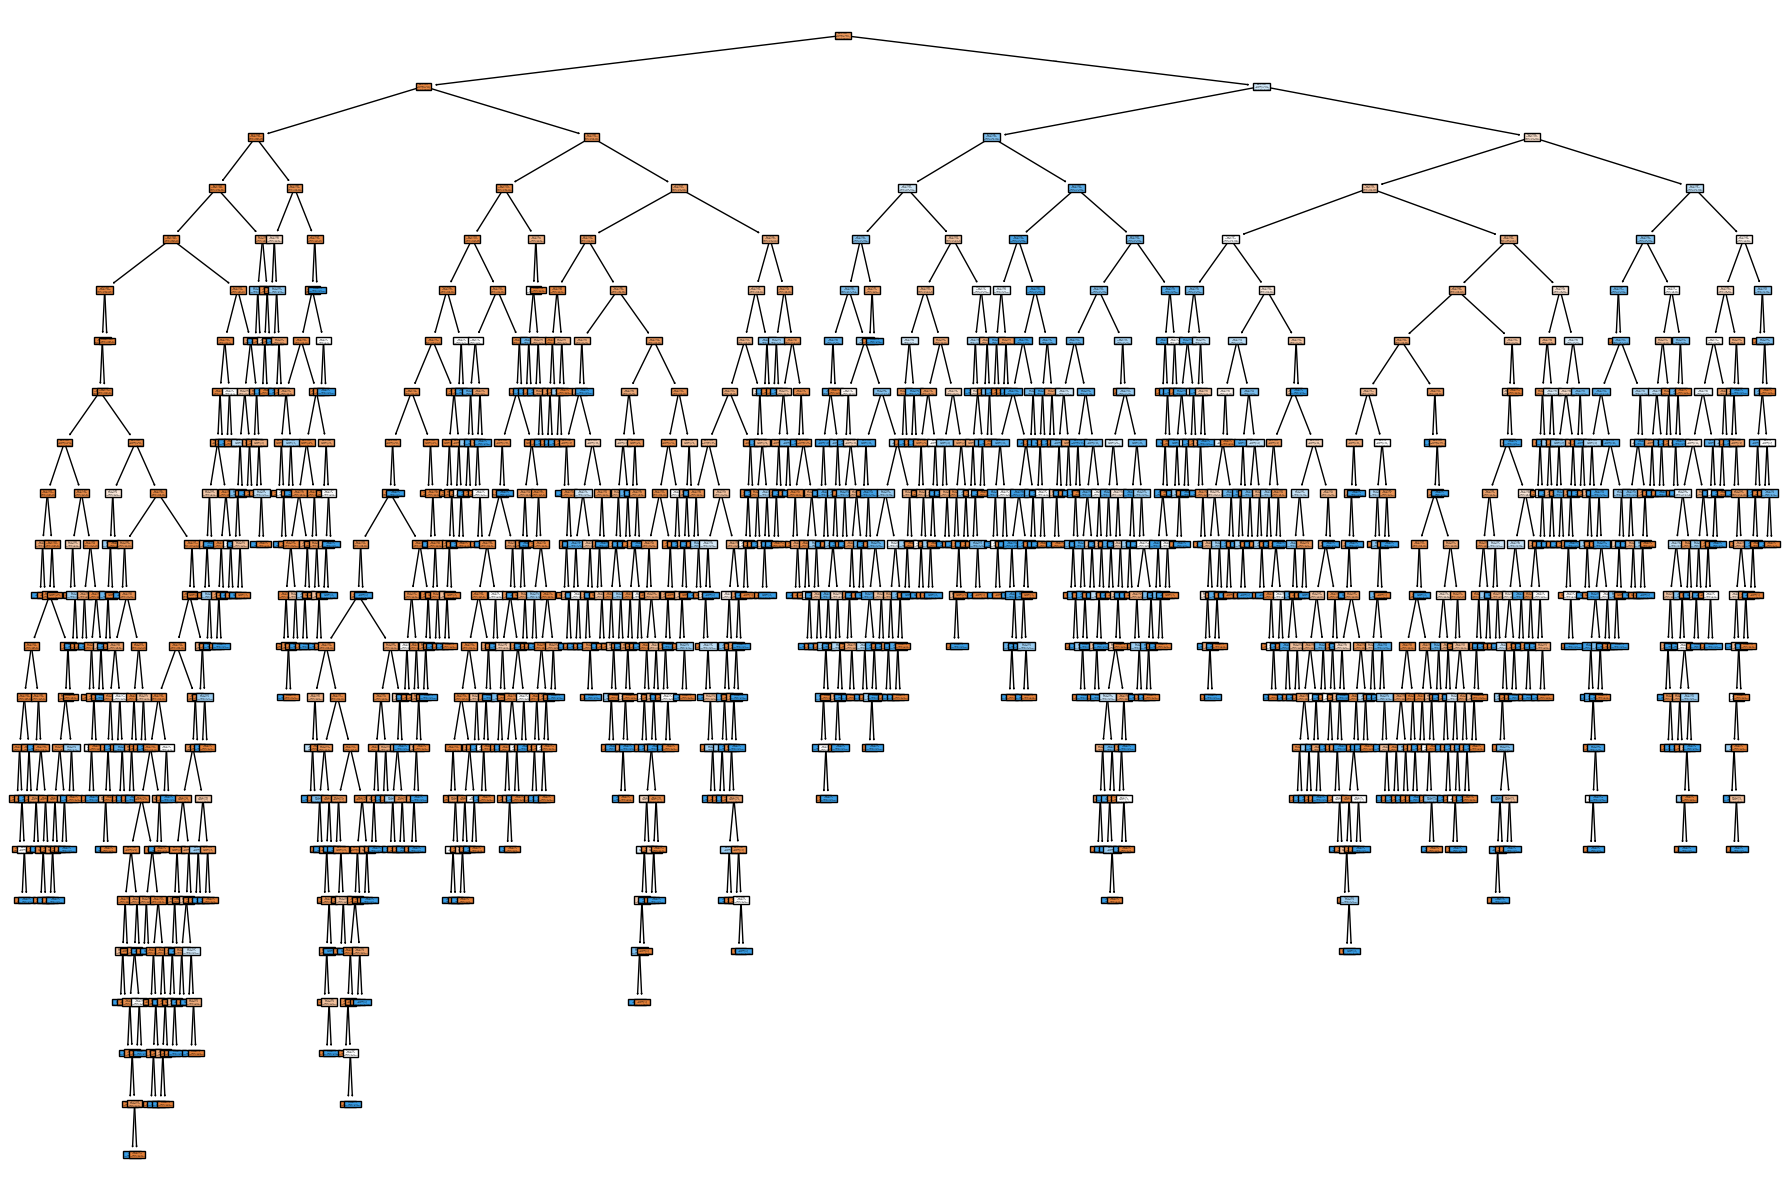

In [44]:
plt.figure(figsize=(18,12))

plot_tree(
    dt_classifier,
    feature_names = X.columns,
    class_names = ["No Purchase", "Made Purchase"], 
    filled=True,
)

plt.tight_layout()
plt.show()

# massively overfitting model

## Findings:-
1. we used neHotEncoder and your StandardScaler on the entire dataset before doing the train-test split
   - training data peeks at the distribution, categories, means, and variances of the test data which leads to data leakage

2. As we didnt use any hyperparameter tuning features, the tree is overfitting
    - training test score is 1 but test score is 0.57 which means the model memorized the training data and didnt generalise it

---
## <u>Decision Tree classifier with hyperparameter pruning</u>
- We will use industry standard order from now on, its a bit tricky so will take some time to le

1. <u>Train Test Split</u>

In [19]:
X = shop_data.drop(columns = ["Revenue"])
y = shop_data["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

2. <u>Feature Encoding</u>

In [24]:
# We need to separate numbers from text so we can treat them differently
numerical_columns = X.select_dtypes(include="number").columns.tolist()
categorical_columns = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# rather than just scaling and encoding the whole training data which leads to data leakage, we make something similar to pipeline 
# columntransfer looks at each column, and then uses standard scaler or ohe depending on the type of column
# we use this preprocesser in the model pipeline later
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns), # applies StandardScaler ONLY to the numerical_columns
        
        # applies OneHotEncoder ONLY to the categorical_columns.
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), categorical_columns)
    ]
)

preprocessor.set_output(transform="pandas") # optional, makes sure the output is in df not in np array

X_train_transformed = preprocessor.fit_transform(X_train) # we will use this to get ccp alphas later

# encode for labels

le = LabelEncoder()
y_train = le.fit_transform(y_train) # Learn the rules and transform the training target
y_test = le.transform(y_test) # ONLY transform the test target based on what was learned

3. <u>create and train model</u>

In [27]:
# grow a full tree
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train_transformed, y_train) # training on the scaled data

# Calculate the mathematical breaking points (alphas)
path = full_tree.cost_complexity_pruning_path(X_train_transformed, y_train)

# Take every 10th alpha to reduce complexity of the model
ccp_alphas_reduced = path.ccp_alphas[::10]

# build pipeline
steps = [
    ("prep", preprocessor), # using the preprocesser in the same pipeline as making the model
    ("dt", DecisionTreeClassifier())
]
pipeline = Pipeline(steps)

# build parameter grid
param_grid = {
    "dt__max_depth": [3, 5, 7, 10], 
    "dt__min_samples_split": [15, 25, 30],
    "dt__min_samples_leaf" : [10, 25, 50],
    "dt__ccp_alpha": ccp_alphas_reduced
}

# create a blueprint using GridSearchCV
dt_classifier_cv = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,               # 5 internal splits for cross validation
    scoring="f1",       # according to assignment
    n_jobs=-1           # Use all computer CPU cores to run as fast as possible
)

# finally make and train the model
# preprocessing and training in the same step
dt_classifier_cv.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'dt__ccp_alpha': array([0.0000...36090799e-02]), 'dt__max_depth': [3, 5, ...], 'dt__min_samples_leaf': [10, 25, ...], 'dt__min_samples_split': [15, 25, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


3. <u>Evaluate</u>

In [28]:
y_pred_training = dt_classifier_cv.predict(X_train)
y_pred_test = dt_classifier_cv.predict(X_test)

print("Best hyper parameters : ", dt_classifier_cv.best_params_)
print("\nDecision Tree Classifier (with leakage free hyperparamter Pruning) :-\n")
print("Training F1 Score : ", f1_score(y_train, y_pred_training))
print("Test F1 Score : ", f1_score(y_test, y_pred_test))

Best hyper parameters :  {'dt__ccp_alpha': np.float64(0.0), 'dt__max_depth': 7, 'dt__min_samples_leaf': 50, 'dt__min_samples_split': 15}

Decision Tree Classifier (with leakage free hyperparamter Pruning) :-

Training F1 Score :  0.6739705326785039
Test F1 Score :  0.6221590909090909


4. <u>Plot Tree</u>

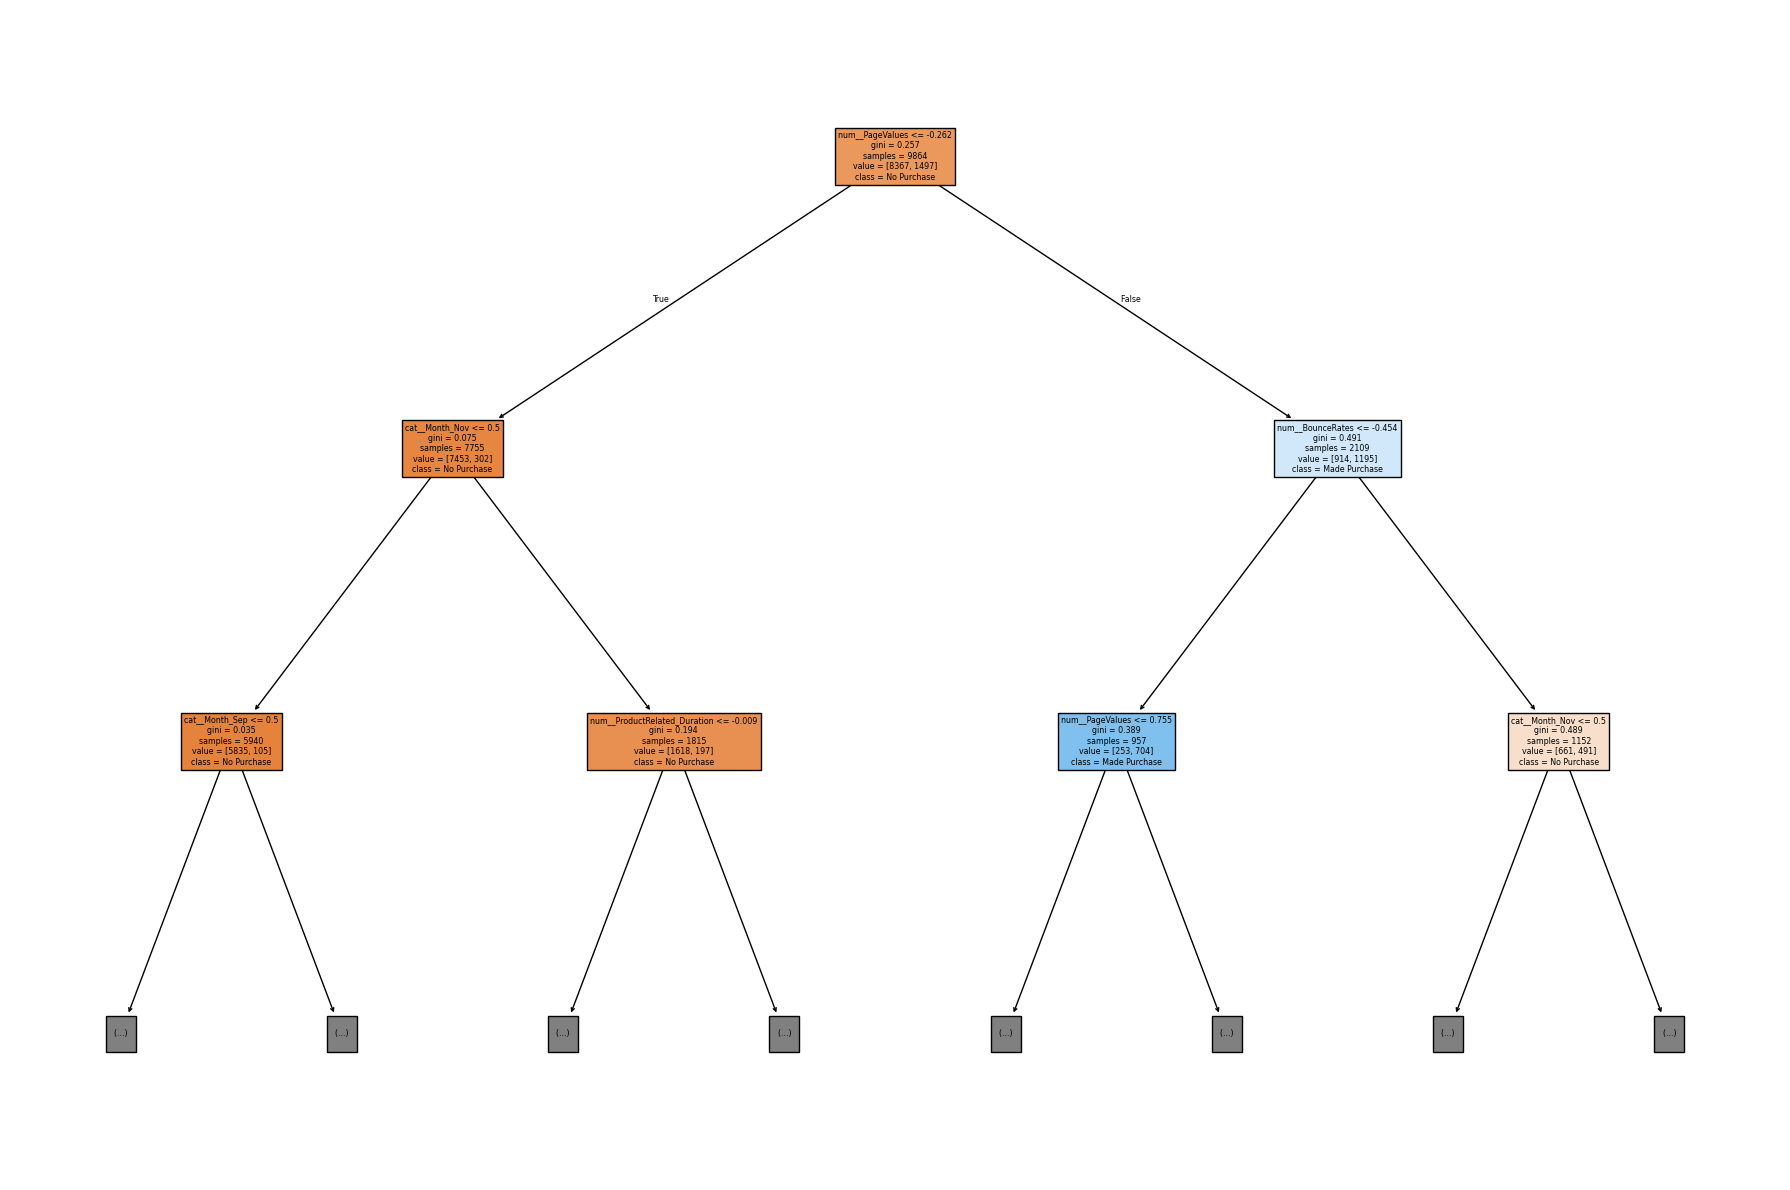

In [34]:
plt.figure(figsize=(18, 12))

# find the best pipeline used to make so many blueprints
best_pipeline = dt_classifier_cv.best_estimator_ 

# from the best blueprint, find the best dt model
best_dt = best_pipeline.named_steps["dt"] 

# from the best pipeline, find the the best dt model, and from that dt model get the feature column names as they arent same as X
feature_names = best_pipeline.named_steps["prep"].get_feature_names_out()

# Draw the tree
plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=["No Purchase", "Made Purchase"], 
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

## findings:-
1. this time we prevented the data leakage cuz we split the data first and while encoding or scaling
    - we used a sub pipeline that ultimately was a part of the main model pipeline which makes sure that the training phase of the model doesnt peek into the testing numbers like mean, distribution etc

2. this time the training score is 0.67 and testing score is 0.62
    - A drop of only around 5% between the open-book training exam and the completely blind test exam means are model is balanced although the score itself is a bit low but the par score is above 0.55 as written in assignment